<a href="https://colab.research.google.com/github/kelakov/computational-chemistry-analysis/blob/main/Chemometric_lessons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA

# 1. Read the generated CSV dataset
df = pd.read_csv("synthetic_nir_chemometrics.csv")

# 2. Slice into matrices (X = spectra variables, y = response analyte value)
X = df.iloc[:, 2:].values          # Column index 2 to end are wavelength attributes
y = df["Concentration_Y"].values  # Target reference vector

print(f"Spectral array shape: {X.shape}") # Expects (40, 50)
print(f"Target properties shape: {y.shape}") # Expects (40,)


Spectral array shape: (40, 50)
Target properties shape: (40,)


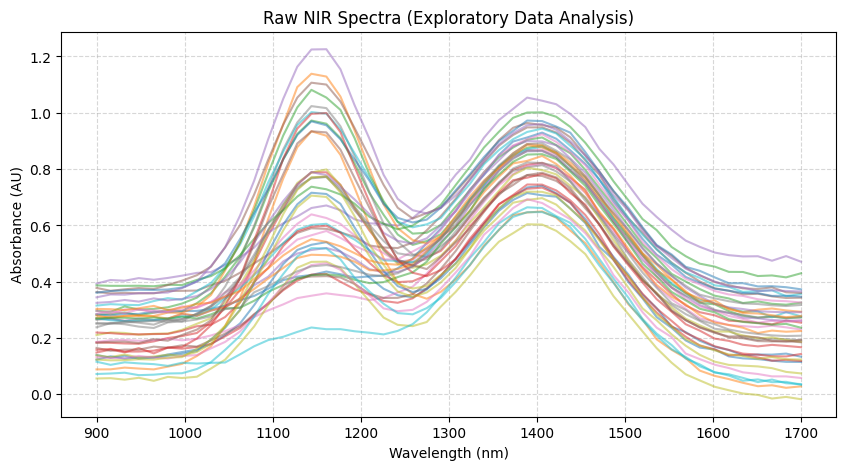

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("synthetic_nir_chemometrics.csv")

# 2. Extract wavelength column names and convert them to numbers for the X-axis
wavelength_cols = df.columns[2:]
# FIXED: Changed 'nm_' to 'W_' to correctly extract the numerical wavelength value
wavelengths = np.array([float(col.replace('W_', '')) for col in wavelength_cols])

# 3. Extract the actual spectral matrix (rows = samples, cols = wavelengths)
X_raw = df[wavelength_cols].values

# 4. Plot all 40 spectral lines
plt.figure(figsize=(10, 5))
for i in range(len(X_raw)):
    plt.plot(wavelengths, X_raw[i, :], alpha=0.5)

plt.title("Raw NIR Spectra (Exploratory Data Analysis)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance (AU)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data & extract values as before
df = pd.read_csv("synthetic_nir_chemometrics.csv")
wavelength_cols = df.columns[2:]
wavelengths = np.array([float(col.replace('W_', '')) for col in wavelength_cols])
X_raw = df[wavelength_cols].values

# 2. Apply SNV Preprocessing
# We calculate the mean and standard deviation per sample (axis=1) and scale
X_snv = np.zeros_like(X_raw)
for i in range(X_raw.shape[0]):
    X_snv[i, :] = (X_raw[i, :] - np.mean(X_raw[i, :])) / np.std(X_raw[i, :])

# 3. Plot the freshly cleaned SNV spectra
plt.figure(figsize=(10, 5))
for i in range(len(X_snv)):
    plt.plot(wavelengths, X_snv[i, :], alpha=0.5)

plt.title("SNV Preprocessed NIR Spectra (Baseline Cleared)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Standardized Absorbance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

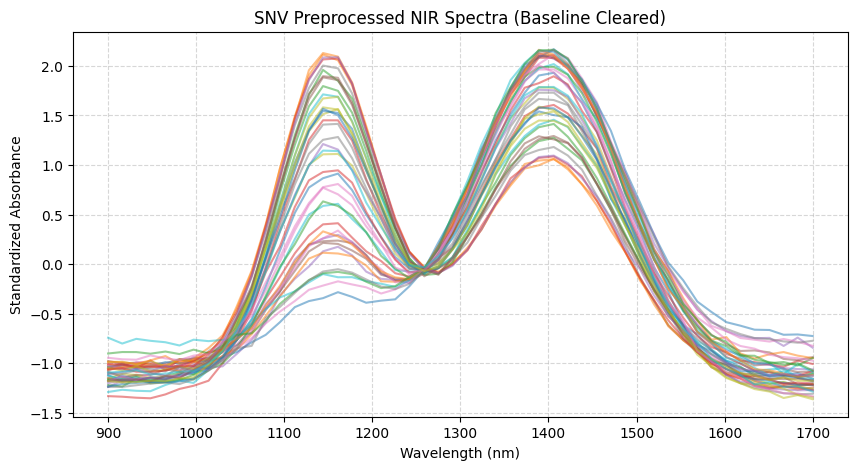

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data & extract values as before
df = pd.read_csv("synthetic_nir_chemometrics.csv")
wavelength_cols = df.columns[2:]
wavelengths = np.array([float(col.replace('W_', '')) for col in wavelength_cols])
X_raw = df[wavelength_cols].values

# 2. Apply SNV Preprocessing
# We calculate the mean and standard deviation per sample (axis=1) and scale
X_snv = np.zeros_like(X_raw)
for i in range(X_raw.shape[0]):
    X_snv[i, :] = (X_raw[i, :] - np.mean(X_raw[i, :])) / np.std(X_raw[i, :])

# 3. Plot the freshly cleaned SNV spectra
plt.figure(figsize=(10, 5))
for i in range(len(X_snv)):
    plt.plot(wavelengths, X_snv[i, :], alpha=0.5)

plt.title("SNV Preprocessed NIR Spectra (Baseline Cleared)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Standardized Absorbance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

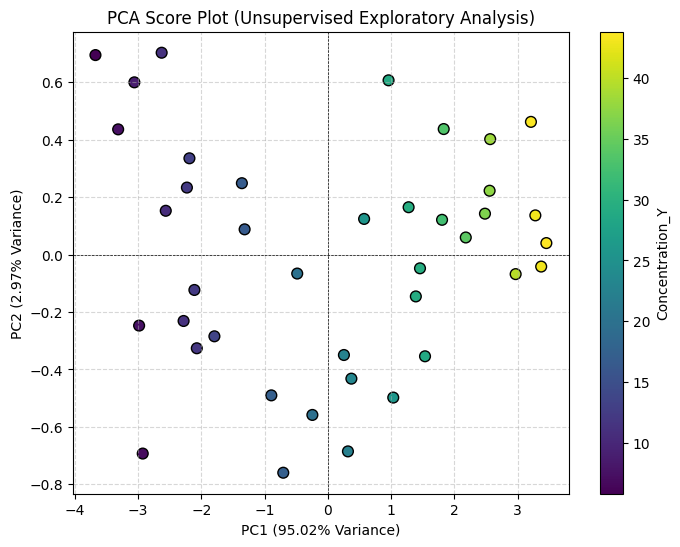

In [ ]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to calculate the first 2 components
pca = PCA(n_components=2)
scores = pca.fit_transform(X_snv)

# 2. Extract how much total information (variance) each component captures
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# 3. Create the 2D Score Plot
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], c=df["Concentration_Y"], cmap="viridis", s=60, edgecolors='k')

# Add labels and a colorbar to see if groupings relate to concentration
colorbar = plt.colorbar()
colorbar.set_label("Concentration_Y")

plt.title("PCA Score Plot (Unsupervised Exploratory Analysis)")
plt.xlabel(f"PC1 ({var_pc1:.2f}% Variance)")
plt.ylabel(f"PC2 ({var_pc2:.2f}% Variance)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

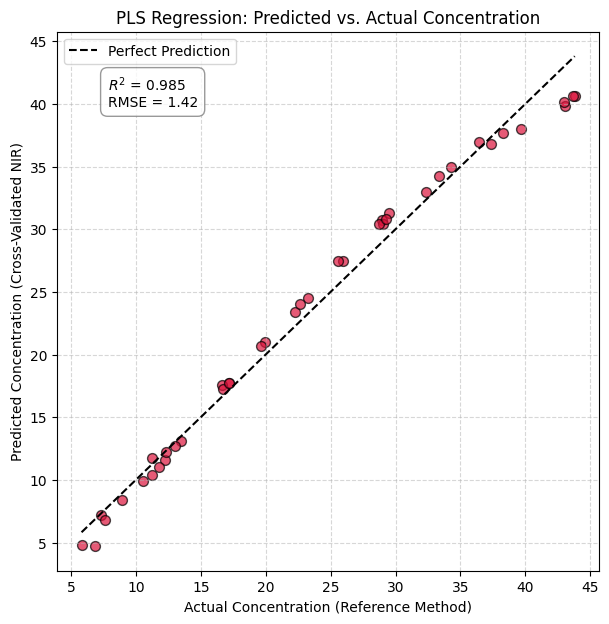

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, root_mean_squared_error

# 1. Target vector
y = df["Concentration_Y"].values

# 2. Initialize PLS with 2 latent variables (components)
pls = PLSRegression(n_components=2)

# 3. Use Cross-Validation to get "blind" predictions for every sample
y_cv = cross_val_predict(pls, X_snv, y, cv=5)

# 4. Calculate performance metrics
r2 = r2_score(y, y_cv)
rmse = root_mean_squared_error(y, y_cv)

# 5. Plot Predicted vs. Actual Concentration
plt.figure(figsize=(7, 7))
plt.scatter(y, y_cv, color='crimson', alpha=0.7, edgecolors='k', s=50)

# Draw a perfect 1:1 line for reference
ideal_line = [y.min(), y.max()]
plt.plot(ideal_line, ideal_line, color='black', linestyle='--', linewidth=1.5, label='Perfect Prediction')

plt.title("PLS Regression: Predicted vs. Actual Concentration")
plt.xlabel("Actual Concentration (Reference Method)")
plt.ylabel("Predicted Concentration (Cross-Validated NIR)")
plt.text(y.min()+2, y.max()-4, f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Inline Multivariate Titration Dataset (Volume vs 3 Wavelengths)
mva_data = """Volume_mL,Wavelength_A,Wavelength_B,Wavelength_C
0.0,0.95,0.05,0.12
2.0,0.93,0.06,0.11
4.0,0.94,0.04,0.14
6.0,0.91,0.07,0.13
8.0,0.88,0.09,0.15
10.0,0.85,0.12,0.18
12.0,0.81,0.16,0.22
14.0,0.76,0.21,0.27
16.0,0.68,0.28,0.34
18.0,0.55,0.41,0.45
20.0,0.38,0.57,0.61
22.0,0.21,0.74,0.78
24.0,0.12,0.83,0.86
26.0,0.08,0.87,0.91
28.0,0.05,0.91,0.93
30.0,0.06,0.92,0.95
32.0,0.04,0.94,0.92
34.0,0.05,0.93,0.96
36.0,0.03,0.95,0.94
38.0,0.04,0.94,0.95
40.0,0.05,0.93,0.97"""

df_mva = pd.read_csv(io.StringIO(mva_data))

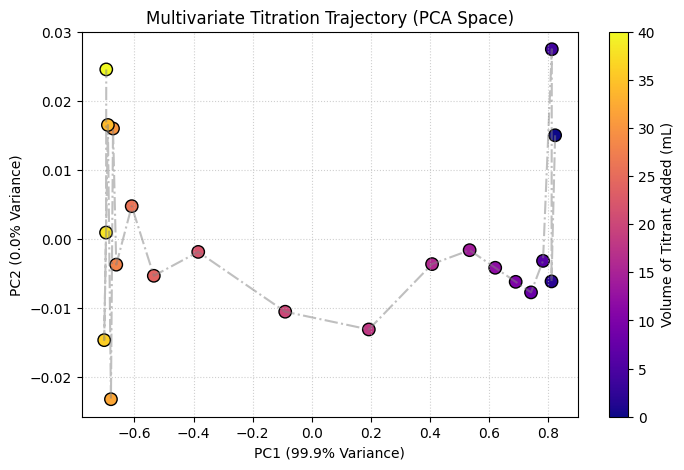

In [ ]:
# 2. Extract only the spectral columns (Variables)
X = df_mva[["Wavelength_A", "Wavelength_B", "Wavelength_C"]].values

# 3. Fit PCA to reduce the 3 wavelengths down to Principal Components
pca = PCA(n_components=2)
scores = pca.fit_transform(X)

# 4. Plot the Multivariate Reaction Trajectory
plt.figure(figsize=(8, 5))
scatter = plt.scatter(scores[:, 0], scores[:, 1], c=df_mva["Volume_mL"], cmap="plasma", s=80, edgecolors='k')
plt.plot(scores[:, 0], scores[:, 1], color="gray", linestyle="-.", alpha=0.5) # Connect the steps

colorbar = plt.colorbar(scatter)
colorbar.set_label("Volume of Titrant Added (mL)")

plt.title("Multivariate Titration Trajectory (PCA Space)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()